<a href="https://colab.research.google.com/github/OmkarRahate2004/Thiranex_Internship/blob/main/Thiranex_p3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q plotly

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
plt.style.use('ggplot')

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include='object'))

Shape: (891, 15)

Columns:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Categorical Summary:


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [ ]:
# Copy dataset
data = df.copy()

# Fill missing values
data['age'].fillna(data['age'].median(), inplace=True)
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)
data['embark_town'].fillna(data['embark_town'].mode()[0], inplace=True)

# Drop column with too many missing values
data.drop('deck', axis=1, inplace=True)

# Check again
data.isnull().sum()

/tmp/ipykernel_4215/3939645586.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(), inplace=True)
/tmp/ipykernel_4215/3939645586.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


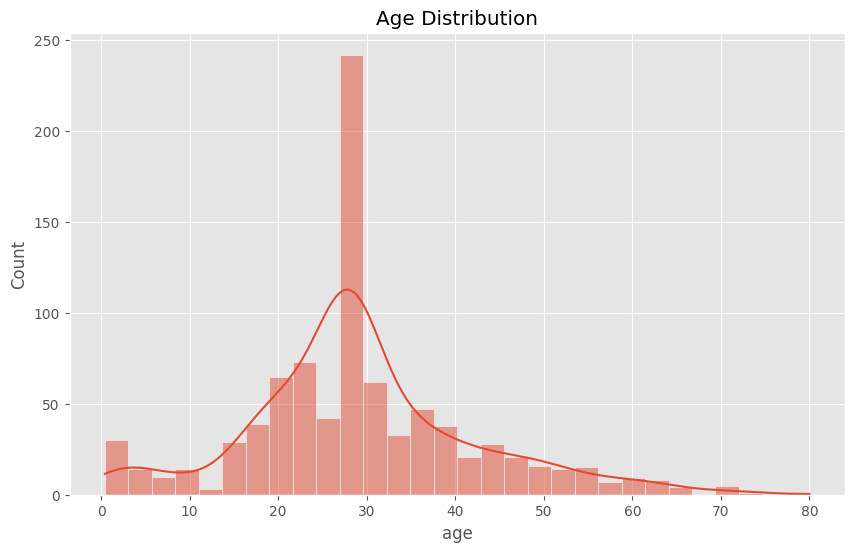

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

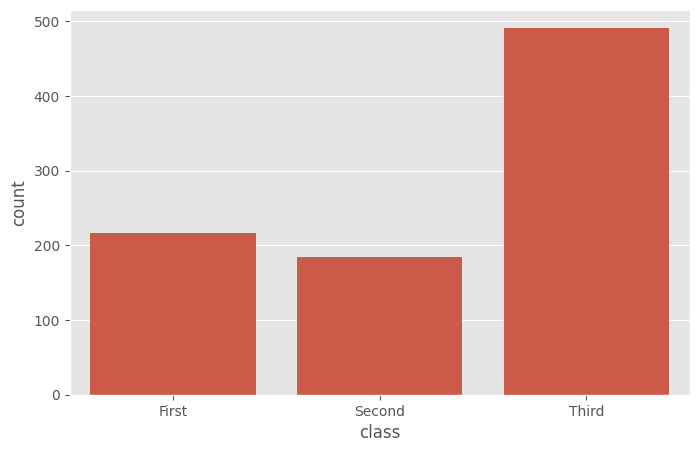

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='class', data=data)
plt.show()

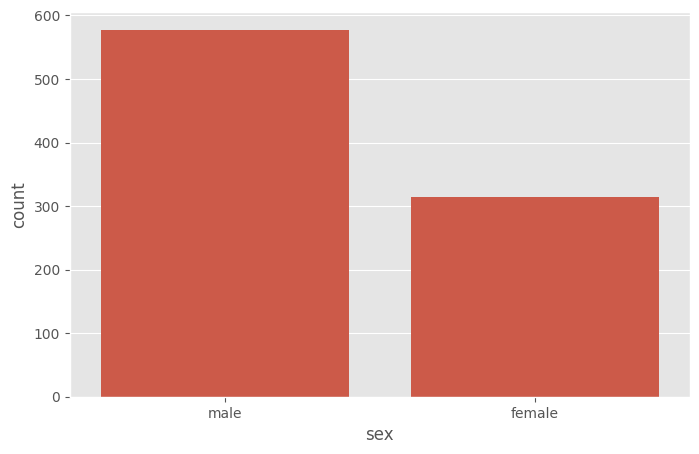

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='sex', data=data)
plt.show()

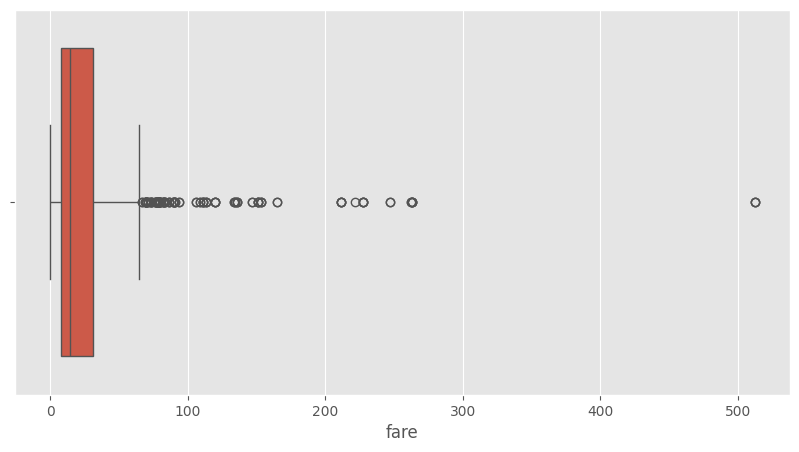

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data['fare'])
plt.show()

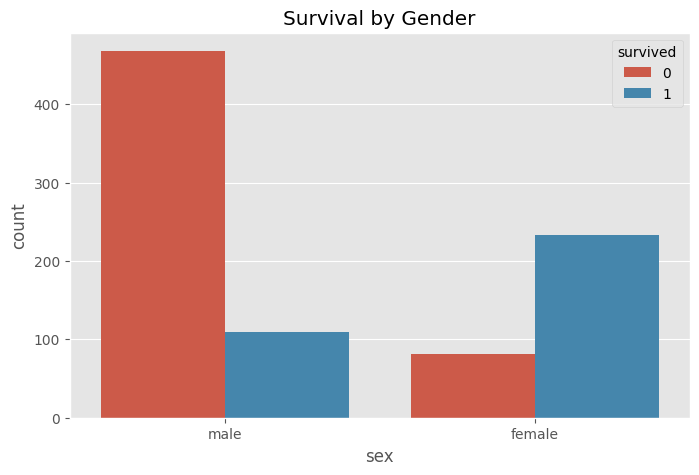

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='sex', hue='survived', data=data)
plt.title('Survival by Gender')
plt.show()

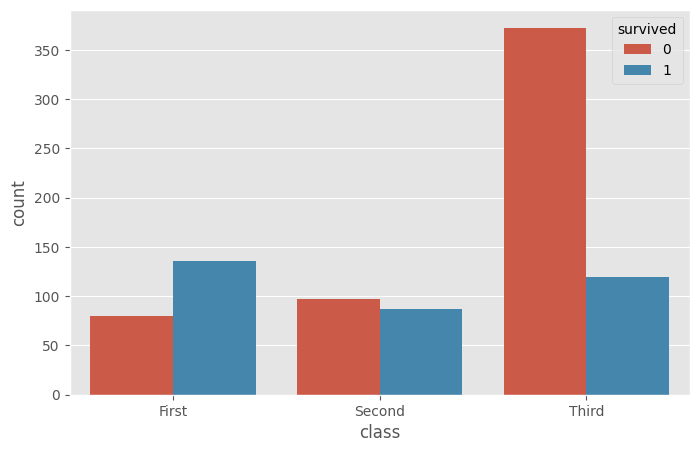

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='class', hue='survived', data=data)
plt.show()

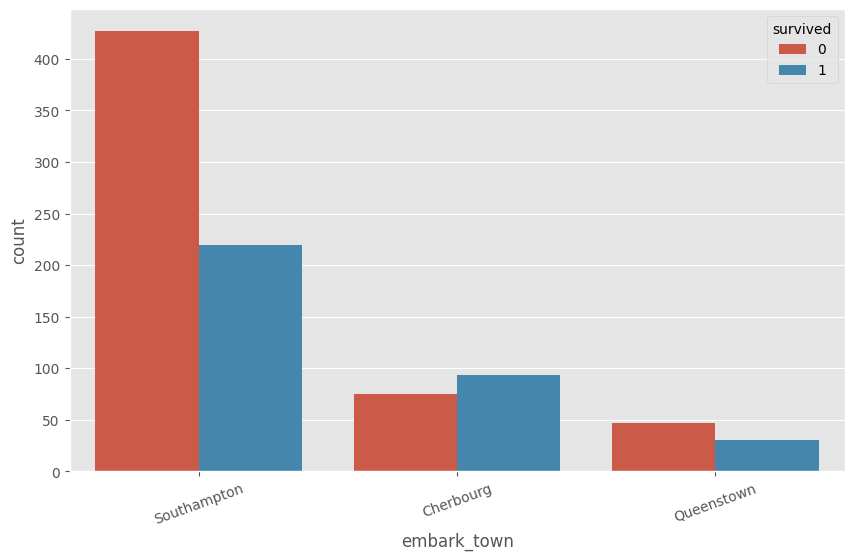

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='embark_town', hue='survived', data=data)
plt.xticks(rotation=20)
plt.show()

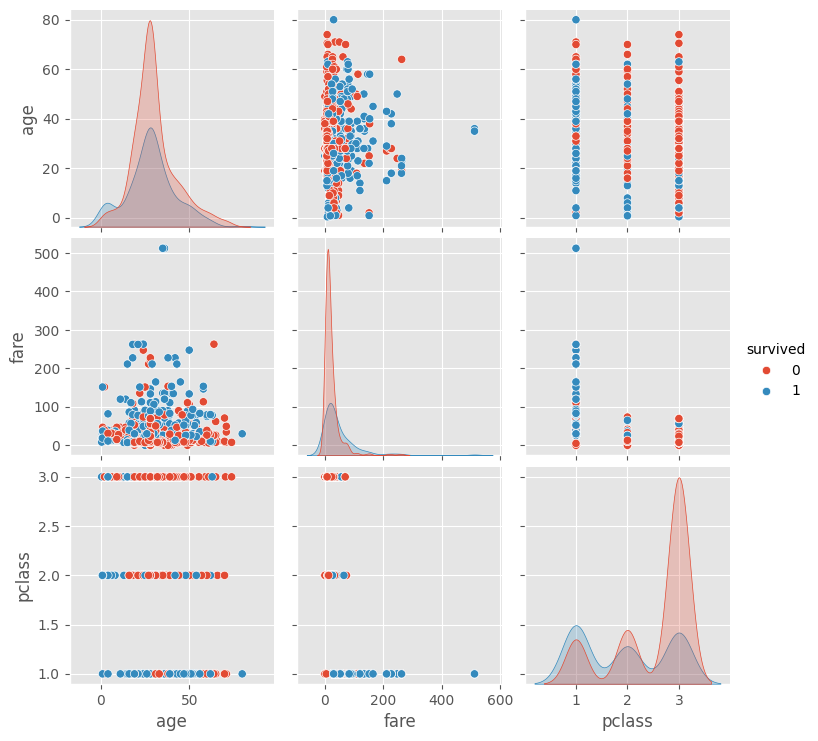

In [ ]:
sns.pairplot(
    data[['survived','age','fare','pclass']],
    hue='survived'
)
plt.show()

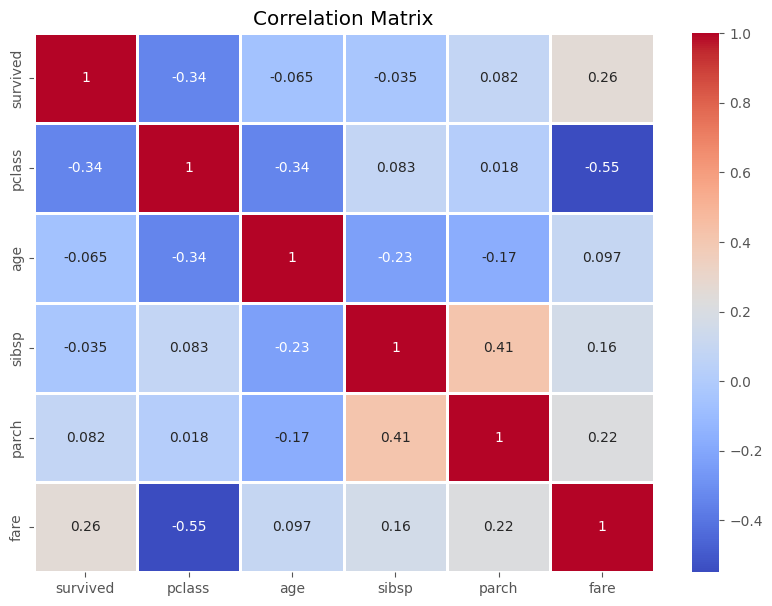

In [ ]:
numeric = data.select_dtypes(include=np.number)
corr = numeric.corr()
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1
)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
#FEATURE ENGINERRING
data['Family_Size'] = data['sibsp'] + data['parch'] + 1

data['Age_Group'] = pd.cut(
    data['age'],
    bins=[0,12,18,35,60,100],
    labels=['Child','Teen','Young Adult','Adult','Senior']
)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,Family_Size,Age_Group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,Young Adult


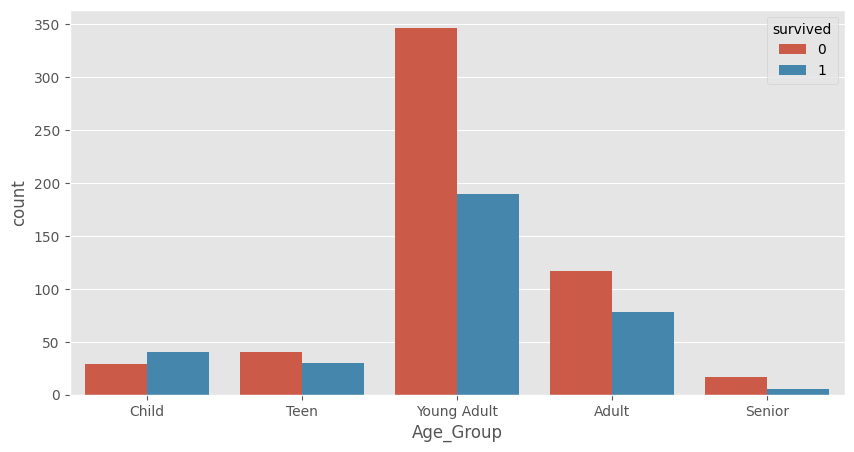

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Age_Group',
    hue='survived',
    data=data
)
plt.show()

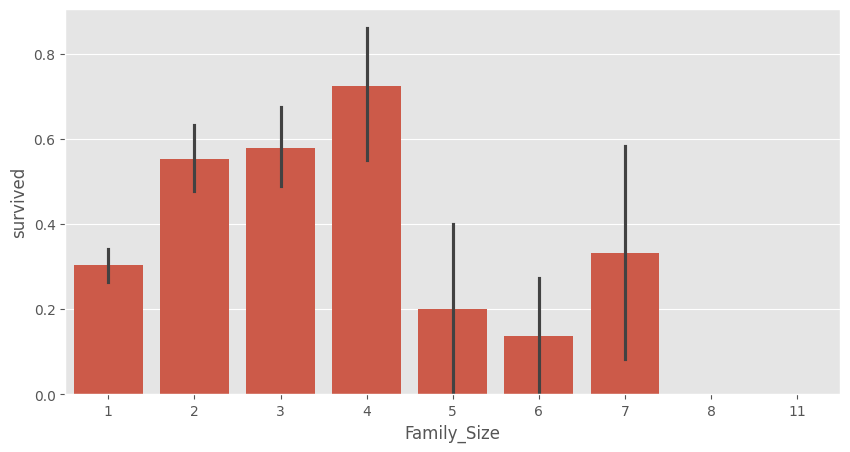

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='Family_Size',
    y='survived',
    data=data
)
plt.show()

In [ ]:
fig = px.pie(
    data,
    names='survived',
    title='Survival Distribution'
)
fig.show()

In [ ]:
fig = px.histogram(
    data,
    x='class',
    color='survived',
    barmode='group',
    title='Passenger Class vs Survival'
)
fig.show()

In [ ]:
fig = px.histogram(
    data,
    x='age',
    color='survived',
    nbins=30,
    title='Age Distribution by Survival'
)
fig.show()

In [ ]:
fig = px.scatter(
    data,
    x='age',
    y='fare',
    color='survived',
    size='Family_Size',
    hover_data=['sex','class'],
    title='Age vs Fare'
)
fig.show()

In [ ]:
fig = make_subplots(
    rows=2,
    cols=2,
    specs=[
        [{'type':'pie'}, {'type':'bar'}],
        [{'type':'scatter'}, {'type':'histogram'}]
    ],
    subplot_titles=(
        'Survival Distribution',
        'Passenger Class',
        'Age vs Fare',
        'Age Distribution'
    )
)

# Pie
fig.add_trace(
    go.Pie(
        labels=data['survived'].value_counts().index,
        values=data['survived'].value_counts().values
    ),
    row=1,
    col=1
)

# Bar
class_survival = pd.crosstab(
    data['class'],
    data['survived']
)

for col in class_survival.columns:
    fig.add_trace(
        go.Bar(
            x=class_survival.index,
            y=class_survival[col],
            name=f'Survived={col}'
        ),
        row=1,
        col=2
    )

# Scatter
fig.add_trace(
    go.Scatter(
        x=data['age'],
        y=data['fare'],
        mode='markers'
    ),
    row=2,
    col=1
)

# Histogram
fig.add_trace(
    go.Histogram(
        x=data['age']
    ),
    row=2,
    col=2
)

fig.update_layout(
    height=800,
    width=1200,
    title='Titanic Interactive Dashboard',
    showlegend=True
)
fig.show()